
COMPARAÇÃO DE PERFORMANCE POR CANAL DE AQUISIÇÃO


,canal_aquisicao,total_pedidos,ticket_medio,taxa_cancelamento
2,Redes Sociais,3761,"R$ 2,657.17",11.67%
0,Indicação,3658,"R$ 2,565.98",12.38%
3,Tráfego Pago,3965,"R$ 2,553.51",30.74%
1,Orgânico,3616,"R$ 2,521.15",11.78%


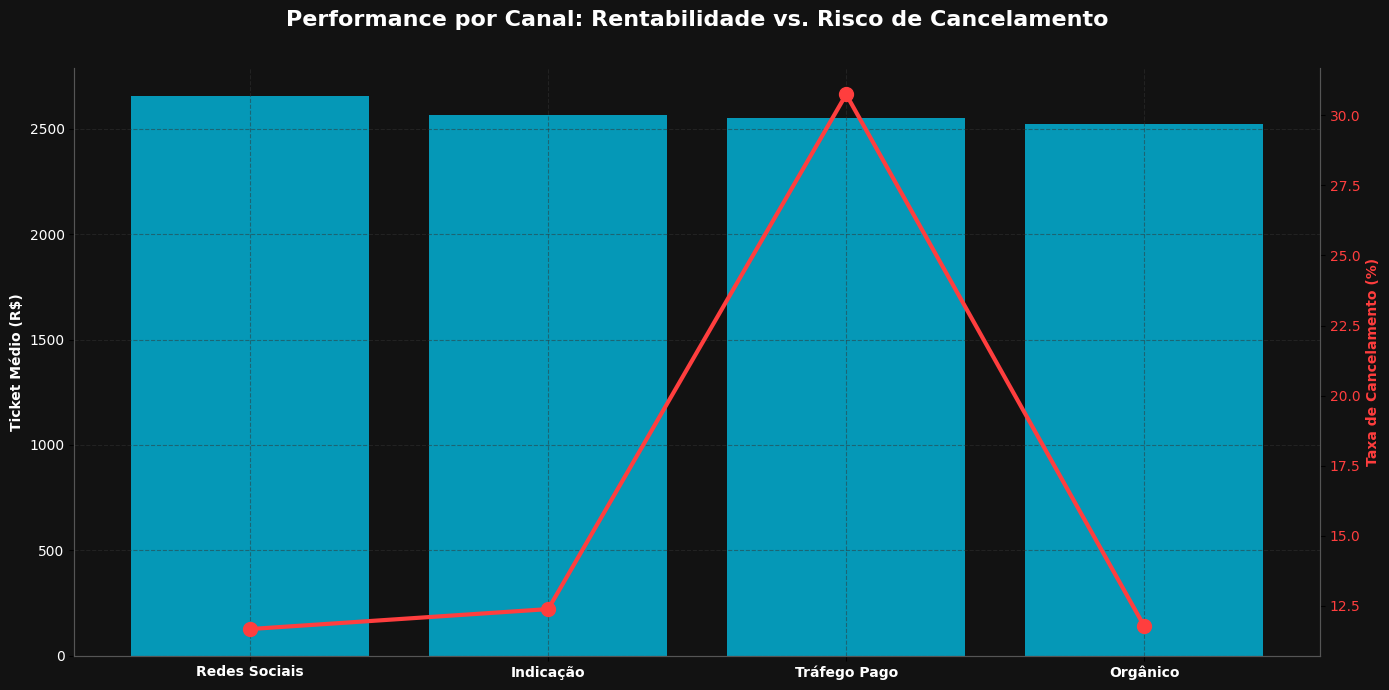

In [5]:
#5) Qual canal de aquisição de clientes apresenta a maior taxa de cancelamento de pedidos? E qual gera o maior valor médio de compra? Cruzar clientes → pedidos.

import pandas as pd
import matplotlib.pyplot as plt

df_pedidos = pd.read_csv('../data/pedidos.csv')
df_clientes = pd.read_csv('../data/clientes.csv')
df_completo = pd.merge(df_pedidos, df_clientes, left_on='cliente_id', right_on='id', how="inner", validate="many_to_many")

mapeamento_canais = {
    'redes_sociais': 'Redes Sociais',
    'indicação': 'Indicação',
    'paid_search': 'Tráfego Pago', 
    'orgânico': 'Orgânico'
}
df_completo['canal_aquisicao'] = df_completo['canal_aquisicao'].map(mapeamento_canais).fillna(df_completo['canal_aquisicao'].str.title().str.replace('_', ' '))

df_completo['is_cancelado'] = df_completo['status'].apply(lambda x: 1 if x == 'cancelado' else 0)

analise_canais = df_completo.groupby('canal_aquisicao').agg(
    total_pedidos=('id_x', 'count'),
    pedidos_cancelados=('is_cancelado', 'sum'),
    ticket_medio=('valor_total', 'mean')
).reset_index()

analise_canais['taxa_cancelamento'] = (analise_canais['pedidos_cancelados'] / analise_canais['total_pedidos']) * 100
analise_canais = analise_canais.sort_values(by='ticket_medio', ascending=False)

print("\n" + "="*70)
print("COMPARAÇÃO DE PERFORMANCE POR CANAL DE AQUISIÇÃO")
print("="*70)

df_exibicao = analise_canais.copy()
df_exibicao['ticket_medio'] = df_exibicao['ticket_medio'].apply(lambda x: f'R$ {x:,.2f}')
df_exibicao['taxa_cancelamento'] = df_exibicao['taxa_cancelamento'].apply(lambda x: f'{x:.2f}%')

display(df_exibicao[['canal_aquisicao', 'total_pedidos', 'ticket_medio', 'taxa_cancelamento']])

COR_FUNDO = '#121212'
fig, ax1 = plt.subplots(figsize=(14, 7), facecolor=COR_FUNDO)
ax1.set_facecolor(COR_FUNDO)

bars = ax1.bar(analise_canais['canal_aquisicao'], analise_canais['ticket_medio'], color='#00D2FF', alpha=0.7, label='Ticket Médio (R$)')
ax1.set_ylabel('Ticket Médio (R$)', color='white', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='white')

ax2 = ax1.twinx()
ax2.plot(analise_canais['canal_aquisicao'], analise_canais['taxa_cancelamento'], color='#FF3E3E', marker='o', linewidth=3, markersize=10, label='Taxa de Cancelamento (%)')
ax2.set_ylabel('Taxa de Cancelamento (%)', color='#FF3E3E', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#FF3E3E')

plt.title('Performance por Canal: Rentabilidade vs. Risco de Cancelamento', fontsize=16, fontweight='bold', color='white', pad=30)

ax1.set_xticks(range(len(analise_canais['canal_aquisicao'])))
ax1.set_xticklabels(analise_canais['canal_aquisicao'], color='white', fontweight='bold')

ax1.grid(color='#333333', linestyle='--', alpha=0.5)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_color('#555555')
    ax.spines['left'].set_color('#555555')
    ax.spines['right'].set_color('#555555')

plt.tight_layout()
plt.show()